In [ ]:
# Preprocessing setup for the Book-Crossing dataset
# This notebook uses the local CSV files stored in data/raw-dataset-books.

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Display settings make the summary tables easier to read in the notebook.
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

DATA_DIR = Path("data/raw-dataset-books")
BOOKS_PATH = DATA_DIR / "Books.csv"
RATINGS_PATH = DATA_DIR / "Ratings.csv"
USERS_PATH = DATA_DIR / "Users.csv"


/kaggle/input/book-recommendation-dataset/Ratings.csv
/kaggle/input/book-recommendation-dataset/Users.csv
/kaggle/input/book-recommendation-dataset/Books.csv


In [ ]:
# Load the raw datasets from the local repo folder.
books = pd.read_csv(BOOKS_PATH, low_memory=False)
ratings = pd.read_csv(RATINGS_PATH, low_memory=False)
users = pd.read_csv(USERS_PATH, low_memory=False)

datasets = {"Books": books, "Ratings": ratings, "Users": users}

print("Dataset shapes:")
for name, df in datasets.items():
    print(f"{name}: {df.shape}")

print("\nColumn names:")
for name, df in datasets.items():
    print(f"{name}: {df.columns.tolist()}")


In [ ]:
# Check missing values in each raw dataset.
for name, df in datasets.items():
    missing_values = df.isna().sum()
    missing_values = missing_values[missing_values > 0]
    print(f"\n{name} missing values:")
    if missing_values.empty:
        print("No missing values found.")
    else:
        print(missing_values.sort_values(ascending=False))

# Remove duplicate rows from each raw table before any filtering.
books = books.drop_duplicates().copy()
ratings = ratings.drop_duplicates().copy()
users = users.drop_duplicates().copy()

print("\nShapes after removing duplicate rows:")
for name, df in {"Books": books, "Ratings": ratings, "Users": users}.items():
    print(f"{name}: {df.shape}")


In [ ]:
# Keep only explicit ratings. Implicit interactions have Book-Rating == 0 and are removed.
ratings = ratings[ratings["Book-Rating"] > 0].copy()
print("Ratings shape after keeping explicit ratings only:", ratings.shape)
print("Unique ratings remaining:", ratings["Book-Rating"].value_counts().sort_index().to_dict())


In [ ]:
# Merge ratings with book metadata using ISBN, then remove sparse users and books.
cleaned_ratings = ratings.merge(books, on="ISBN", how="inner")
print("Shape after merging Ratings.csv with Books.csv:", cleaned_ratings.shape)

# Remove users with fewer than 5 ratings and books with fewer than 5 ratings.
# The filtering is repeated until both conditions are stable.
previous_shape = None
while previous_shape != cleaned_ratings.shape:
    previous_shape = cleaned_ratings.shape

    user_counts = cleaned_ratings["User-ID"].value_counts()
    active_users = user_counts[user_counts >= 5].index
    cleaned_ratings = cleaned_ratings[cleaned_ratings["User-ID"].isin(active_users)].copy()

    book_counts = cleaned_ratings["ISBN"].value_counts()
    active_books = book_counts[book_counts >= 5].index
    cleaned_ratings = cleaned_ratings[cleaned_ratings["ISBN"].isin(active_books)].copy()

print("Shape after removing sparse users and books:", cleaned_ratings.shape)


In [ ]:
# Summary statistics for the cleaned graph-ready interaction table.
summary_stats = pd.DataFrame(
    {
        "Metric": [
            "Number of users",
            "Number of books",
            "Number of ratings",
            "Average rating",
        ],
        "Value": [
            cleaned_ratings["User-ID"].nunique(),
            cleaned_ratings["ISBN"].nunique(),
            len(cleaned_ratings),
            round(cleaned_ratings["Book-Rating"].mean(), 3),
        ],
    }
)

print(summary_stats.to_string(index=False))


In [ ]:
# Visualize the cleaned ratings distribution and the most active entities.
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(cleaned_ratings["Book-Rating"], bins=10, color="#2A6F97", edgecolor="white")
ax.set_title("Rating Distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

top_books = cleaned_ratings["Book-Title"].value_counts().head(20)
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_books.index[::-1], top_books.values[::-1], color="#A23B72")
ax.set_title("Top 20 Most Rated Books")
ax.set_xlabel("Number of Ratings")
ax.set_ylabel("Book Title")
plt.tight_layout()
plt.show()

top_users = cleaned_ratings["User-ID"].value_counts().head(20)
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_users.index.astype(str)[::-1], top_users.values[::-1], color="#F18F01")
ax.set_title("Top 20 Most Active Users")
ax.set_xlabel("Number of Ratings")
ax.set_ylabel("User ID")
plt.tight_layout()
plt.show()


/opt/conda/lib/python3.7/site-packages/numpy/lib/function_base.py:2551: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar)
/opt/conda/lib/python3.7/site-packages/numpy/lib/function_base.py:2480: RuntimeWarning: divide by zero encountered in true_divide
  c *= np.true_divide(1, fact)


['Horse Whisperer', 'Kitchen Confidential: Adventures in the Culinary Underbelly'] <class 'list'>


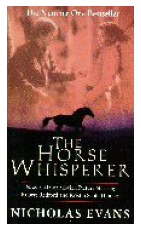

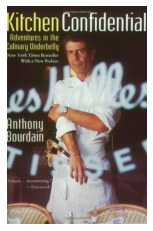

In [ ]:
# Save the cleaned interactions table for downstream GNN preprocessing.
output_path = Path("cleaned_ratings.csv")
cleaned_ratings.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to: {output_path.resolve()}")


0    Eureka
1    Eureka
Name: Book-Title, dtype: object


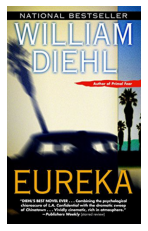

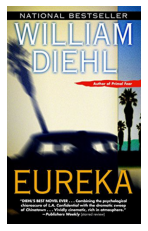

In [ ]:
# Final preview so the cleaned dataset can be inspected quickly.
print("Final cleaned dataset shape:", cleaned_ratings.shape)
cleaned_ratings.head()
